# Q7 — CRR Binomial Model vs Black–Scholes

A risky asset price $S_t$ can be modelled either by a continuous-time GBM

$$dS_t = r_c S_t\,dt + \sigma S_t\,d\beta_t, \quad S_0 = 120,$$

or by an $N$-step CRR binomial tree with per-step parameters

$$u = \sigma\sqrt{\Delta t}, \quad d = -\sigma\sqrt{\Delta t}, \quad r = r_c\Delta t, \quad q = \frac{r - d}{u - d} = \frac{1}{2} + \frac{r_c\sqrt{\Delta t}}{2\sigma}.$$

It can be shown that as $\Delta t \to 0$:

$$\log S^*_T \xrightarrow{d} \mathcal{N}\!\left(\log S_0 + \left(r_c - \tfrac{1}{2}\sigma^2\right)T,\;\sigma^2 T\right),$$

i.e. the binomial model converges in distribution to GBM. Consequently $C^E_0(N) \to C^E_{\mathrm{BS}}$ as $N \to \infty$.

**Parameters:** $S_0 = K = 120$, $r_c = 0.1$, $\sigma = 0.03$, $T = 1$.

---

## Part 1 — Black–Scholes Closed-Form Price

$$C^E_{\mathrm{BS}} = S_0\Phi(d_1) - Ke^{-r_c T}\Phi(d_2), \qquad d_1 = \frac{\ln(S_0/K) + \left(r_c + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}.$$

Since $S_0 = K$ (at-the-money), $\ln(S_0/K) = 0$, so $d_1 \approx 3.348$ and $\Phi(d_1) \approx \Phi(d_2) \approx 1$, giving

$$C^E_{\mathrm{BS}} \approx 120(1 - e^{-0.1}) \approx \$11.42.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Q7 parameters
S0    = 120.0
K     = 120.0
rc    = 0.1
sigma = 0.03
T     = 1.0

print("Parameters loaded")

Parameters loaded


In [2]:
def black_scholes_call(S0: float, K: float, rc: float, sigma: float, T: float) -> float:
    """European call price via Black-Scholes closed form."""
    assert sigma > 0 and T > 0, "sigma and T must be positive"
    d1 = (np.log(S0 / K) + (rc + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-rc * T) * norm.cdf(d2)


bs_price = black_scholes_call(S0, K, rc, sigma, T)
print(f"Black-Scholes call price: C^E_BS = {bs_price:.6f}")

Black-Scholes call price: C^E_BS = 11.419894


### Intermediate values (verification)

Expected: $d_1 \approx 3.348$, $d_2 \approx 3.318$, $C^E_{\mathrm{BS}} \approx \$11.42$.

In [3]:
d1 = (np.log(S0 / K) + (rc + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

print(f"d1       = {d1:.4f}")
print(f"d2       = {d2:.4f}")
print(f"Phi(d1)  = {norm.cdf(d1):.6f}")
print(f"Phi(d2)  = {norm.cdf(d2):.6f}")
print(f"C^E_BS   = {bs_price:.4f}")

d1       = 3.3483
d2       = 3.3183
Phi(d1)  = 0.999594
Phi(d2)  = 0.999547
C^E_BS   = 11.4199


---

## Part 2 — CRR Binomial Model

Partition $[0,T]$ into $N$ steps of length $\Delta t = T/N$. Terminal stock prices with $j$ up-moves:

$$S^*_N(j) = S_0(1+u)^j(1+d)^{N-j}, \quad j = 0,\ldots,N.$$

European call payoffs $C_N(j) = \max(S^*_N(j) - K, 0)$, then **backward induction** for $k = N-1,\ldots,0$:

$$C_k(j) = \frac{q\,C_{k+1}(j+1) + (1-q)\,C_{k+1}(j)}{1+r}.$$

The price is $C^E_0 = C_0(0)$.

In [4]:
def crr_call(S0: float, K: float, rc: float, sigma: float, T: float, N: int) -> float:
    """European call price via CRR N-step binomial backward induction."""
    dt = T / N
    u  = sigma * np.sqrt(dt)
    d  = -sigma * np.sqrt(dt)
    r  = rc * dt
    q  = (r - d) / (u - d)

    j   = np.arange(N + 1)
    S_T = S0 * (1 + u)**j * (1 + d)**(N - j)
    C   = np.maximum(S_T - K, 0.0)

    for _ in range(N):
        C = (q * C[1:] + (1 - q) * C[:-1]) / (1 + r)

    return float(C[0])

In [5]:
def plot_crr_convergence(N_values: 'np.ndarray', crr_prices: list, bs_price: float) -> None:
    """CRR binomial prices vs N with Black-Scholes reference line."""
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(N_values, crr_prices, color="steelblue", linewidth=1.2,
            label="CRR binomial price")
    ax.axhline(bs_price, color="crimson", linewidth=1.5, linestyle="--",
               label=f"Black\u2013Scholes: ${bs_price:.4f}")

    ax.set_xlabel(r"Number of binomial steps $N$", fontsize=12)
    ax.set_ylabel(r"European call price $C^E_0$ (USD)", fontsize=12)
    ax.set_title("Convergence of CRR Binomial Model to Black\u2013Scholes", fontsize=13)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig("q7_convergence.png", dpi=150)
    plt.show()

In [6]:
def plot_crr_oscillation(N_values: 'np.ndarray', crr_prices: list, bs_price: float,
                         n_zoom: int = 20) -> None:
    """Zoomed plot for N=1..n_zoom to expose the odd/even oscillation pattern."""
    ns = N_values[N_values <= n_zoom]
    ps = [p for n, p in zip(N_values, crr_prices) if n <= n_zoom]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(ns, ps, color="steelblue", linewidth=1.2, marker="o", markersize=5,
            label="CRR binomial price")
    ax.axhline(bs_price, color="crimson", linewidth=1.5, linestyle="--",
               label=f"Black–Scholes: ${bs_price:.4f}")

    ax.set_xlabel(r"Number of binomial steps $N$", fontsize=12)
    ax.set_ylabel(r"European call price $C^E_0$ (USD)", fontsize=12)
    ax.set_title(f"Odd/even oscillation of CRR price ($N = 1$ to $N = {n_zoom}$)", fontsize=13)
    ax.set_xticks(ns)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig("q7_oscillation.png", dpi=150)
    plt.show()

CRR N=1   : 7.090909
CRR N=100 : 11.414336
BS price  : 11.419894


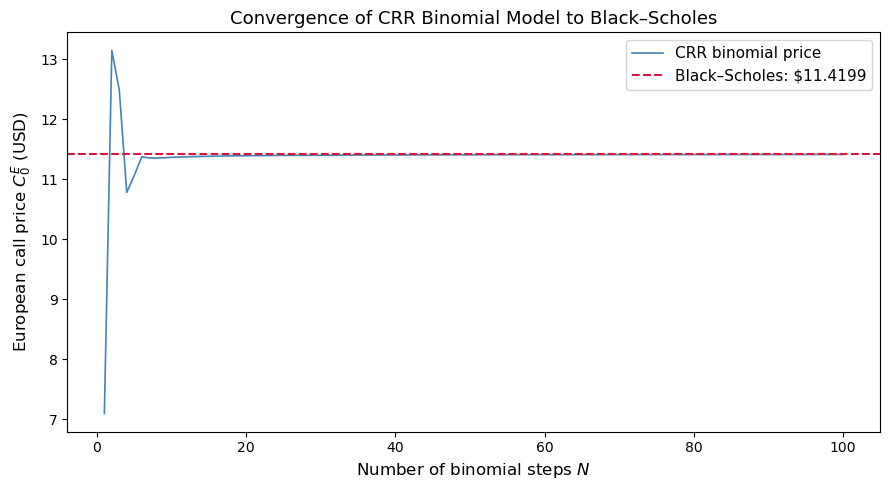

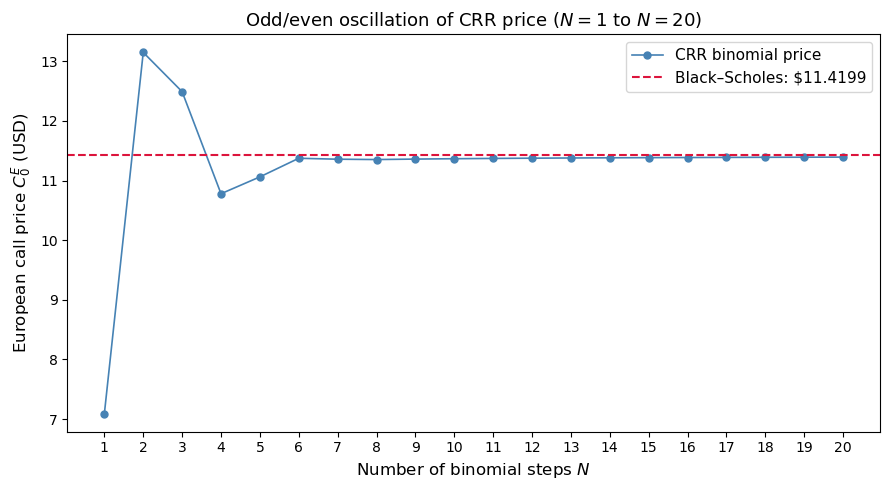

In [7]:
N_values   = np.arange(1, 101)
crr_prices = [crr_call(S0, K, rc, sigma, T, N) for N in N_values]

print(f"CRR N=1   : {crr_prices[0]:.6f}")
print(f"CRR N=100 : {crr_prices[-1]:.6f}")
print(f"BS price  : {bs_price:.6f}")

plot_crr_convergence(N_values, crr_prices, bs_price)
plot_crr_oscillation(N_values, crr_prices, bs_price)

### Discussion

The plot shows $C^E_0(N) \to C^E_{\mathrm{BS}}$ as $N$ increases from 1 to 100. Three features are notable:

1. **Oscillation for small $N$.** As shown clearly in the zoomed plot ($N = 1$ to $20$), the price alternates above and below the Black–Scholes value. This arises because for even $N$ a central node of the binomial tree can land exactly at $K$, whereas for odd $N$ it cannot, causing the approximation to alternate sides of the Black–Scholes price.

2. **Monotone convergence for large $N$.** By $N \approx 30$–50 the oscillations dampen and the binomial price tracks $C^E_{\mathrm{BS}}$ closely, reflecting the distributional convergence $\log S^*_T \xrightarrow{d} \mathcal{N}(\cdot,\cdot)$ stated in the question.

3. **Rate of convergence.** The CRR model converges at rate $O(1/N)$: the error halves when $N$ doubles, consistent with the standard result for binomial approximations to the Black–Scholes formula.